#  Снижение дисперсии в A/B тестах с помощью метода CUPED (на данных маркетплейса Olist)

**Дата:** 04.03.2026

В проекте использован общедоступный набор данных о заказах, оформленных в бразильском интернет-магазине **Olist Store**. Это реальные коммерческие данные. Набор данных содержит информацию о 100 000 заказов, оформленных с 2016 по 2018 год на различных бразильских торговых площадках.

[Ссылка на датасет](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

### Задача
Оценить эффективность маркетинговой кампании в условиях высокой дисперсии целевой метрики (выручка) (наличие городов-миллионников и малых населенных пунктов).

### Схема данных

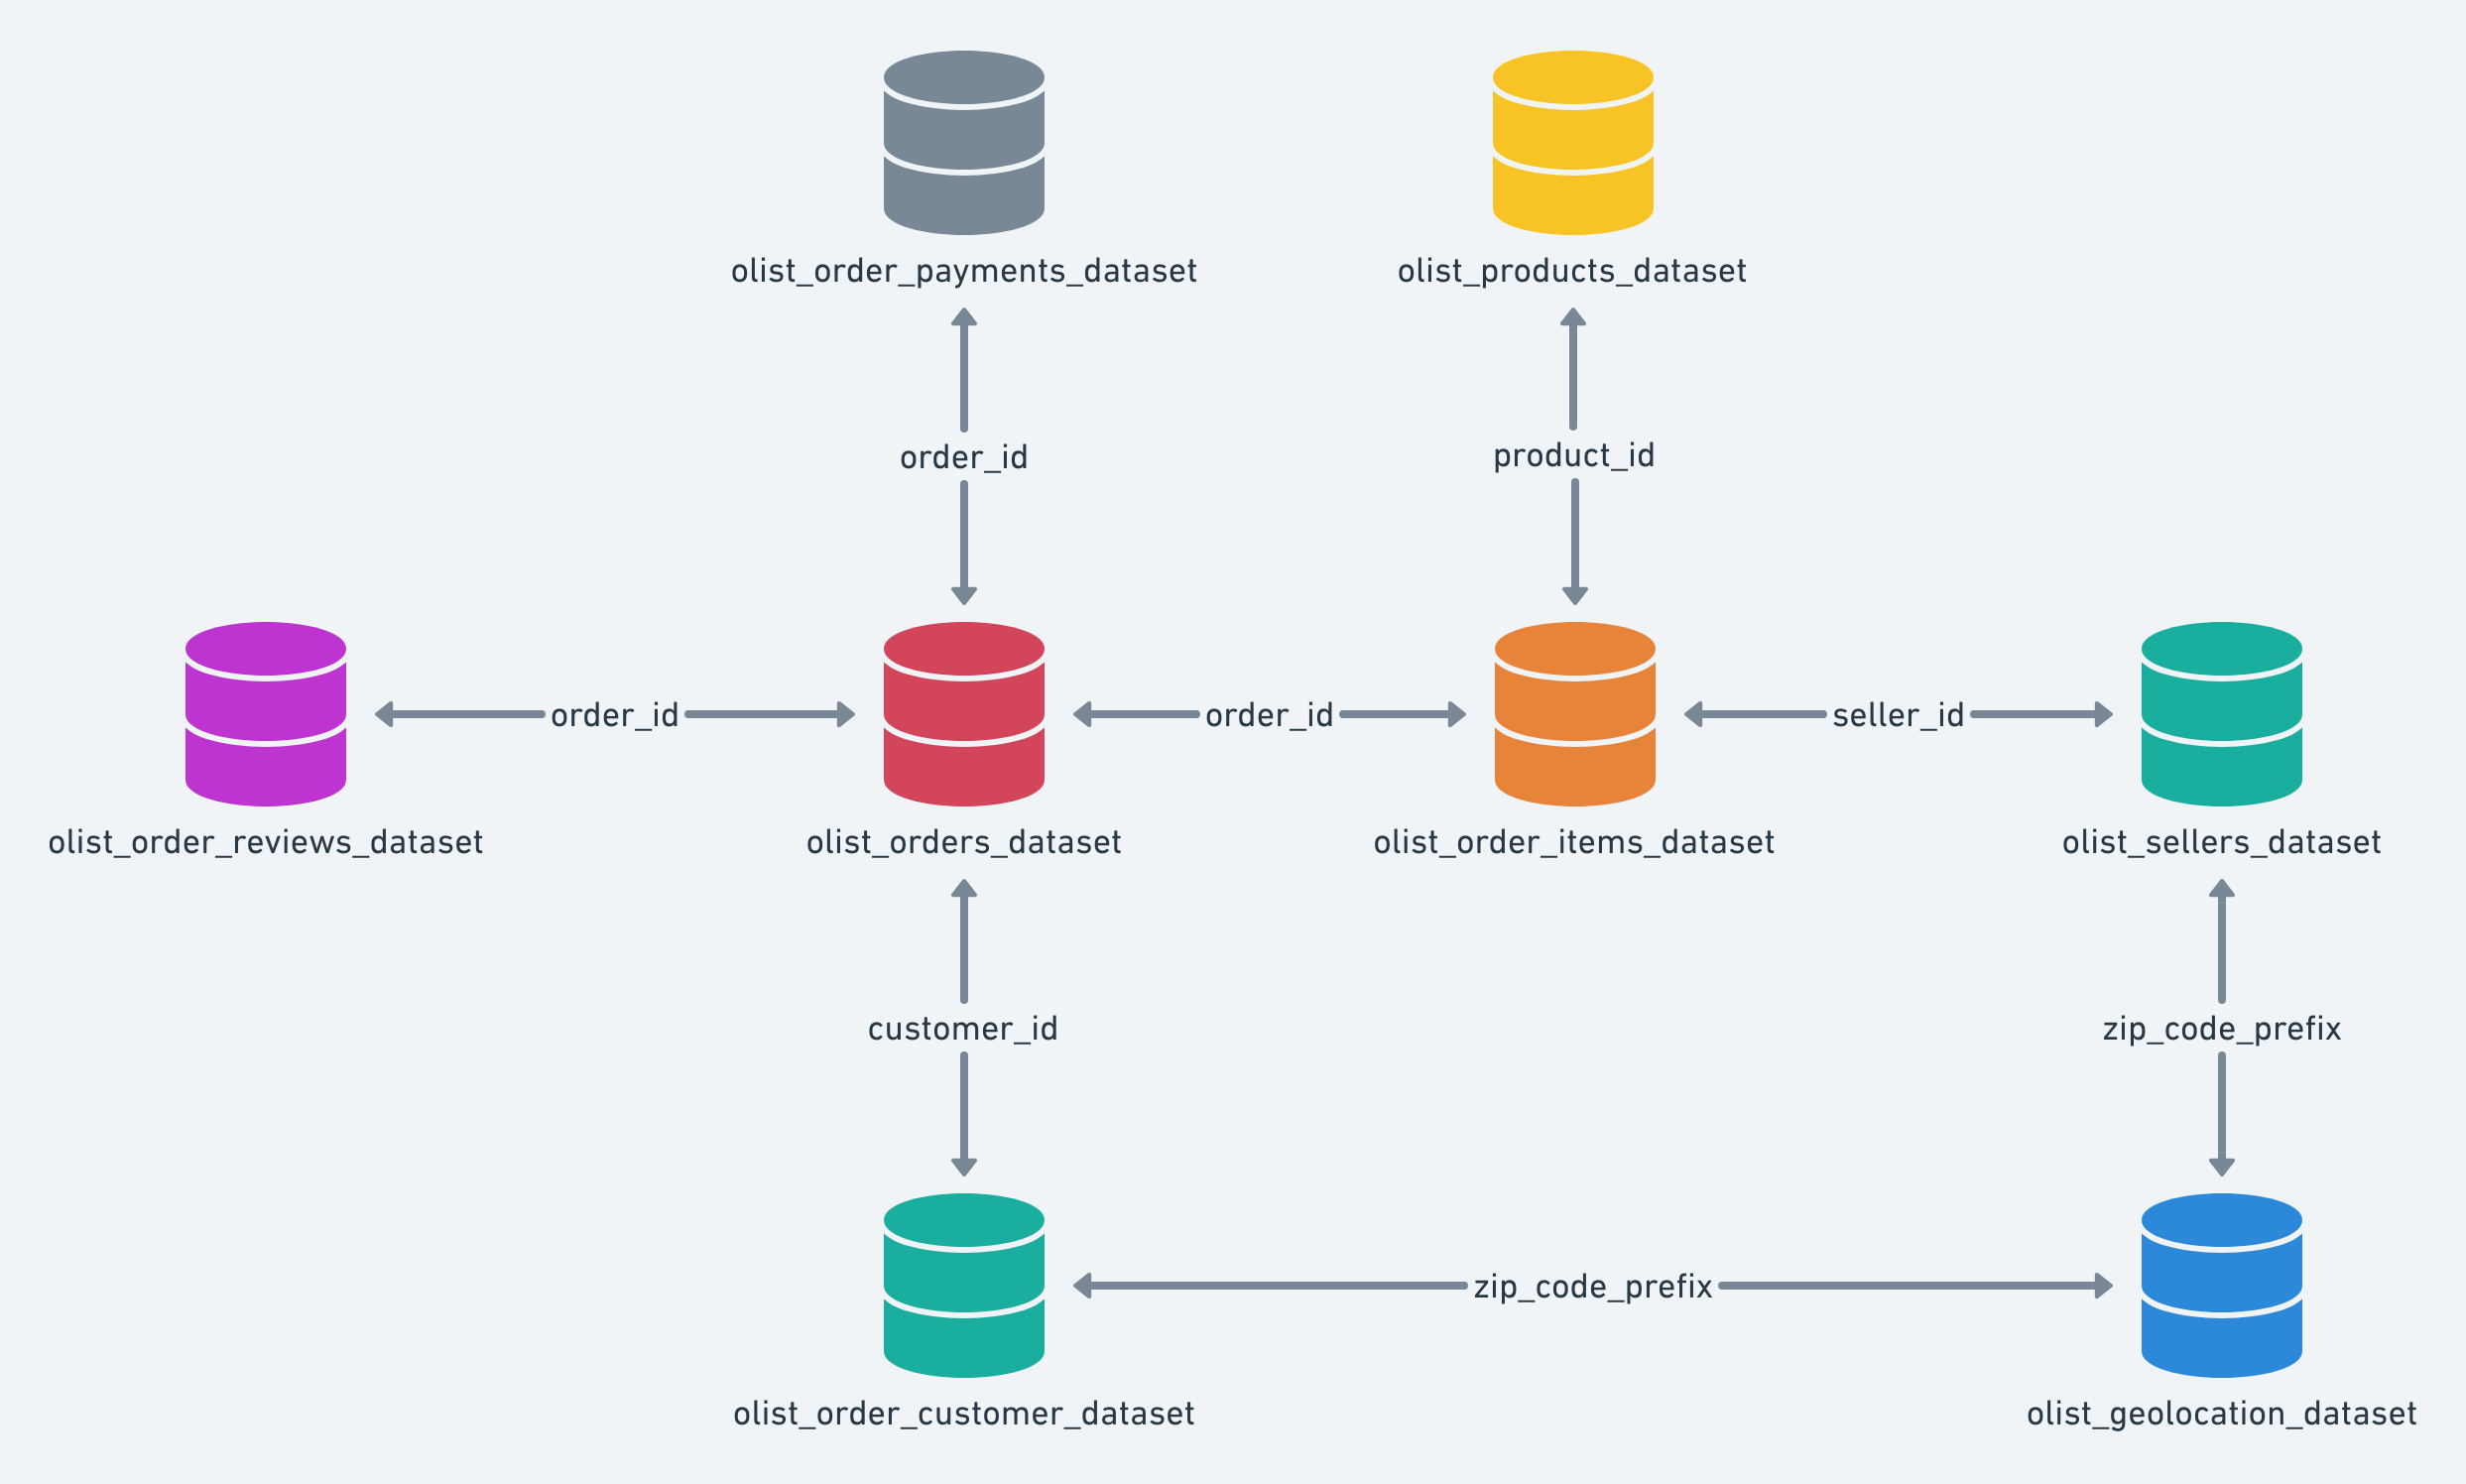

### Данные

Работаем тремя датасетами:  

1. `olist_orders_dataset.csv` - заказы

- order_id - уникальный id заказа
- customer_id  - уникальный идентификатор клиента. Каждый заказ имеет уникальный customer_id
- order_status - статус заказа (доставлен, отправлен и т. д.)
- order_purchase_timestamp - дата и время покупки
- order_approved_at - дата и время подтверждения платежа
- order_delivered_carrier_date - дата и время передачи заказа логистическому партнеру
- order_delivered_customer_date - дата и время доставки заказа клиенту
- order_estimated_delivery_date - предполагаемая дата доставки, о которой клиенту сообщили в момент покупки.
 
2. `olist_order_items_dataset.csv` - товары в каждом заказе.

- order_id - уникальный id заказа
- order_item_id - порядковый номер товара в чеке заказа
- product_id - уникальный идентификатор продукта
- seller_id - уникальный идентификатор продавца
- shipping_limit_date - крайний срок отгрузки, установленный продавцом для передачи заказа логистическому партнеру
- price - цена товара
- freight_value -цена достаки
 
3. `olist_customers_dataset.csv` - 

- customer_id - ключ для связи с таблицей заказов. Каждый заказ имеет уникальный customer_id.
- customer_unique_id - уникальный идентификатор клиента
- customer_zip_code_prefix - 5 цифр почтового индекса клиента
- customer_city - город клиента
- customer_state - штат клиента

### План проекта
1. Загрузка исторических данных и их предобработка
2. Исследовательский анализ исторических данных
3. Исследование результатов А/В эксперимента
4. Выводы

## Загрузка и преобработка данных

### Загрузка библиотек

In [1]:
# Загружаем библиотеку Pandas
import pandas as pd

In [2]:
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Загружаем библиотеку для диаграмм Венна
from matplotlib_venn import venn2

In [4]:
import numpy as np
from scipy import stats as st

In [5]:
# Уменьшение разрешения DPI для графиков 
plt.rcParams['figure.dpi'] = 72

### Загрузка данных и их предобработка

Для уменьшения рутинных действий используем функцию для загрузки файлов.

In [6]:
path = 'd:/datasets/olist/'

In [7]:
def load_data_from_list(file_name, folder=path):
    """
    Функция загружает файл из списка file_name из папки folder
    """
    full_path = f"{folder}{file_name}"
    try:
        df = pd.read_csv(full_path)
        display(f"Файл загружен успешно: {file_name} | Строк: {df.shape[0]}")
        return df
    except Exception as e:
        print(f"Ошибка при загрузке: {file_name}: {e}")
        return None

In [8]:
# Cписок таблиц
list_files = ['olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_customers_dataset.csv']

### Заказы

In [9]:
# Загружаем заказы
df_orders = load_data_from_list(list_files[0])

'Файл загружен успешно: olist_orders_dataset.csv | Строк: 99441'

In [10]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [11]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [12]:
# преобразуем поля из текста в дату
cols_to_fix = ['order_purchase_timestamp', 'order_approved_at',\
               'order_delivered_carrier_date', 'order_delivered_customer_date',\
               'order_estimated_delivery_date']
df_orders[cols_to_fix] = df_orders[cols_to_fix].apply(pd.to_datetime, format='%Y-%m-%d %H:%M:%S')

In [13]:
#Проверим на наличие явных дубликатов в данных по всем столбцам
display(f'Явных дубликатов по всем столбцам: {df_orders.duplicated().sum()}.\
        Это {df_orders.duplicated().sum()/df_orders.shape[0]} %')

'Явных дубликатов по всем столбцам: 0.        Это 0.0 %'

Проверим интервал дат в данных. Нам нужна только дата заказа, поэтому проверяем только ее.

In [14]:
display(f'Интервал дат "order_purchase_timestamp": \
"{df_orders["order_purchase_timestamp"].dt.date.min()} - {df_orders["order_purchase_timestamp"].dt.date.max()}')

'Интервал дат "order_purchase_timestamp": "2016-09-04 - 2018-10-17'

In [15]:
# Смотрим уникальные события воронки
display(f'События воронки: {df_orders['order_status'].unique()}')

"События воронки: ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'\n 'created' 'approved']"

In [16]:
# Смотрим - есть ли аннулированные заказы
display(f'Аннулированных заказов: {df_orders.loc[df_orders["order_status"] == "canceled"].shape[0]}')

'Аннулированных заказов: 625'

In [17]:
# Уберем аннулированные заказы
df_orders = df_orders.loc[df_orders['order_status'] != 'canceled']

In [18]:
display(f'Всего заказов: {df_orders.shape[0]}')

'Всего заказов: 98816'

### Товары в заказах

In [19]:
# Загружаем цены товаров
df_price = load_data_from_list(list_files[1])

'Файл загружен успешно: olist_order_items_dataset.csv | Строк: 112650'

In [20]:
df_price.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [21]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


Нам не все данные нужны, поэтому предобработки, например дат, не будет.

In [22]:
#Проверим на наличие явных дубликатов в данных по всем столбцам
display(f'Явных дубликатов по всем столбцам: {df_price.duplicated().sum()}.\
        Это {df_price.duplicated().sum()/df_price.shape[0]} %')

'Явных дубликатов по всем столбцам: 0.        Это 0.0 %'

In [23]:
# Данные столбца 'price'
display(df_price["price"].describe())

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

### Покупатели

In [24]:
# Загружаем покупателей
df_customers = load_data_from_list(list_files[2])

'Файл загружен успешно: olist_customers_dataset.csv | Строк: 99441'

In [25]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [26]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [27]:
#Проверим на наличие явных дубликатов в данных по всем столбцам
display(f'Явных дубликатов по всем столбцам: {df_customers.duplicated().sum()}.\
        Это {df_customers.duplicated().sum()/df_customers.shape[0]} %')

'Явных дубликатов по всем столбцам: 0.        Это 0.0 %'

In [28]:
display(f'Количество пользователей: {df_customers["customer_id"].nunique()}')

'Количество пользователей: 99441'

In [29]:
display(f'Количество уникальных пользователей: {df_customers["customer_unique_id"].nunique()}')

'Количество уникальных пользователей: 96096'

In [30]:
display(f'Уникальные города: {df_customers["customer_city"].unique()}')

"Уникальные города: ['franca' 'sao bernardo do campo' 'sao paulo' ... 'monte bonito'\n 'sao rafael' 'eugenio de castro']"

In [31]:
display(f'Количество уникальных городов: {df_customers["customer_city"].nunique()}')

'Количество уникальных городов: 4119'

In [32]:
display(f'Уникальные штаты: {df_customers["customer_state"].unique()}')

"Уникальные штаты: ['SP' 'SC' 'MG' 'PR' 'RJ' 'RS' 'PA' 'GO' 'ES' 'BA' 'MA' 'MS' 'CE' 'DF'\n 'RN' 'PE' 'MT' 'AM' 'AP' 'AL' 'RO' 'PB' 'TO' 'PI' 'AC' 'SE' 'RR']"

## Подготовка датасета для метода CUPED

Для применения метода снижения дисперсии **CUPED (Controlled-experiment Using Pre-Experiment Data)** необходимы исторические данные и данные тестового периода.

Считаем, что 

- период ДО ТЕСТА: май 2018.
- период ТЕСТА: июнь 2018.

### Фильтрация и объединение

In [33]:
# Фильтруем данные по дате покупки, а не по дате доставки, т.к. доставка может быть с задержкой и на нее влияет логистика - это другой фактор
df_orders_filtered = df_orders.loc[df_orders['order_purchase_timestamp'].between('2018-05-01', '2018-06-30')].copy()

In [34]:
display(f'Количество записей о заказах: {df_orders_filtered.shape[0]}')

'Количество записей о заказах: 12874'

Добавим к каждому заказу таблицу с товарами.

In [35]:
# Учитываем только стоимость самого заказа, стоимость доставки не учитываем
df= pd.merge(df_orders_filtered[['order_id', 'customer_id', 'order_purchase_timestamp']],\
             df_price[['order_id','price']], on='order_id', how='inner')

In [36]:
display(f'Количество записей: {df.shape[0]}')

'Количество записей: 14819'

Добавим данные о покупателях

In [37]:
df = pd.merge(df, df_customers[['customer_id','customer_unique_id', 'customer_city']], on='customer_id', how='inner')

In [38]:
display(f'Количество записей: {df.shape[0]}')

'Количество записей: 14819'

### Подготовка датасета

Сначала собираем исторические данные по целевой метрике (выручке) за период до начала теста — в нашем случае это месяц (май) - т.н. "ковариата".

In [39]:
# добавим номер месяца 
df['month'] = df['order_purchase_timestamp'].dt.month

Далее, группируем заказы по пользователям - получаем таблицу, где одна строка — это один уникальный клиент (customer_unique_id), и две колонки: сумма в мае и сумма в июне.

In [40]:
# Сводная таблица: сумма покупок каждого юзера по месяцам
df_final = df.pivot_table(
    index='customer_unique_id', 
    columns='month', 
    values='price', 
    aggfunc='sum'
).fillna(0) # Если в мае не покупал — ставим 0

In [41]:
# Переименуем колонки
df_final.columns = ['May', 'June']

In [42]:
# Удалим индекс
df_final = df_final.reset_index()

In [43]:
# Считаем тех, у кого есть данные за оба месяца (суммы > 0)
returning_users = len(df_final[(df_final['May'] > 0) & (df_final['June'] > 0)])

display(f"Количество повторных покупателей: {returning_users}")

'Количество повторных покупателей: 38'

**Вывод:** Анализ показал низкую частоту повторных покупок (Retention) — всего 38 пересечений между маем и июнем на уровне покупателей. Этого объема недостаточно для применения метода CUPED на уровне индивидуальных ID. Перейдем к гео-аналитике на уровень ГОРОДОВ.

In [44]:
# Сводная таблица: сумма покупок каждого города по месяцам
df_cuped = df.pivot_table(
    index='customer_city', 
    columns='month', 
    values='price', 
    aggfunc='sum'
).fillna(0) # Если нет покупок — ставим 0

In [45]:
# Переименуем колонки
df_cuped.columns = ['May', 'June']

In [46]:
# Удалим индекс
df_cuped = df_cuped.reset_index()

In [47]:
# Считаем только те, города, в которых были покупки в обоих месяцах - необходимое условие для применения метода CUPED
returning_cities = len(df_cuped[(df_cuped['May'] > 0) & (df_cuped['June'] > 0)])

display(f"Количество городов с покупками в обоих месяцах: {returning_cities}")

'Количество городов с покупками в обоих месяцах: 651'

**Вывод:** Для повышения мощности теста было принято решение агрегировать данные на уровне городов. Это позволило увеличить выборку до 651 объекта и использовать исторические данные как ковариату.

### Расчет коэффициентов для CUPED

1. Подготовка таблицы

In [48]:
# Оставляем только те города, где были продажи в МАЕ (в периоде ДО ТЕСТА)
df_cuped = df_cuped.loc[df_cuped['May'] > 0].copy()

2. Расчет коэффициента Мю - среднее значение метрики в предпериоде по всей выборке

In [49]:
#  Мю (среднее мая по всем городам выборки)
mu_may = df_cuped['May'].mean()
print(f"Среднее в мае (mu): {mu_may:.2f}")

Среднее в мае (mu): 830.86


3. Расчет коэффициента Тета - доля изменчивости в тестовом периоде, которую можно объяснить историческими данными мая

   Формула = отношение ковариации тестовых и предпериодных данных к дисперсии предпериодных данных (cov/var)

In [50]:
# Вычисляем функцию ковариации- как переменные отклоняются от своих средних значений
# Она возвращает матрицу ковариации: диагональные элементы матрицы — это дисперсии переменных, а внедиагональные — ковариации.
covariance = df_cuped[['June', 'May']].cov().iloc[0, 1] 
display(f"Ковариация (cov): {covariance:.4f}")

'Ковариация (cov): 21435713.6231'

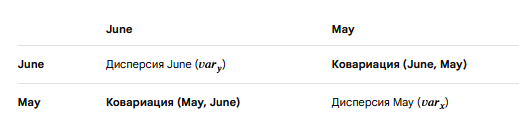

In [51]:
# дисперсия предпериода
variance_may = df_cuped['May'].var()
display(f"Дисперсия предпериода (var): {variance_may:.4f}")

'Дисперсия предпериода (var): 27736076.0010'

In [52]:
# Считаем Тету (Ковариация May/June / Дисперсия May)
theta = covariance / variance_may
display(f"Коэффициент коррекции (theta): {theta:.4f}")

'Коэффициент коррекции (theta): 0.7728'

4. Применяем трансформацию CUPED

Создаем новую колонку со скорректированной выручкой июня.

In [53]:
# Формула: Y_cuped = Y_june - theta * (X_may - mu_may)
df_cuped['June_CUPED'] = df_cuped['June'] - theta * (df_cuped['May'] - mu_may)

## Сравнение дисперсии ДО применения метода CUPED и ПОСЛЕ

Покажем, что ДО применения метода, по "сырым" данным, нельзя применить t-test

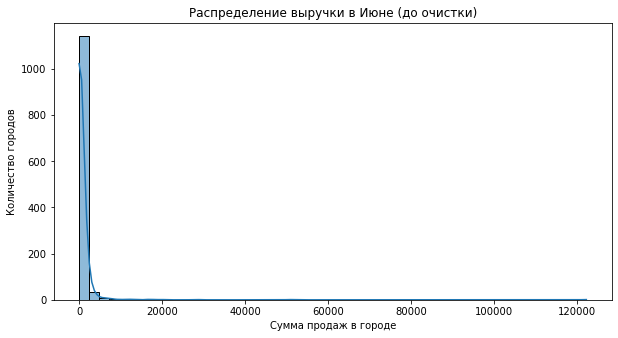

In [54]:
# строим гистограмму распределения выручки
plt.figure(figsize=(10, 5))
sns.histplot(df_cuped['June'], kde=True, bins=50)
plt.title('Распределение выручки в Июне (до очистки)')
plt.xlabel('Сумма продаж в городе')
plt.ylabel('Количество городов')
plt.show()

Видим, что нарушаются предпосылки t-testa: 

- распределение НЕ нормальное
- имеются экстремальных выбросы - тяжелые хвосты (продажи в крупных городах)

Дополнительно проверим данные тестом **Шапиро-Уилка** на нормальность.

- H0 - нулевая гипотеза - данные распределены нормально

- H1 - тестовая гипотеза - данные распределены не нормально

In [55]:
shapiro_test = st.shapiro(df_cuped['June'])
if shapiro_test.pvalue > 0.05:
    display(f"Распределение нормальное,  p-value = {shapiro_test.pvalue:.20f}")
else:
    display(f"Распределение не нормальное, p-value = {shapiro_test.pvalue:.20f}")        

'Распределение не нормальное, p-value = 0.00000000000000000000'

**Вывод:** Первичный анализ данных показал асимметрию распределения и наличие выбросов, тест Шапиро-Уилка отвергает гипотезу о нормальности распределения. В таких условиях классический t-тест имеет низкую мощность и дает ложные результаты. Это обосновывает необходимость применения CUPED для стабилизации метрики и снижения дисперсии.

Теперь сравним дисперсии выручки ДО применения метода CUPED и ПОСЛЕ.

In [56]:
var_before = df_cuped['June'].var() ## до
var_after = df_cuped['June_CUPED'].var() ## после
reduction = (1 - var_after / var_before) * 100

display(f"Дисперсия ДО применения метода CUPED: {var_before:.2f}")
display(f"Дисперсия ПОСЛЕ применения метода CUPED: {var_after:.2f}")
display(f"Снижение дисперсии: {reduction:.2f}%")

'Дисперсия ДО применения метода CUPED: 17089721.92'

'Дисперсия ПОСЛЕ применения метода CUPED: 523217.76'

'Снижение дисперсии: 96.94%'

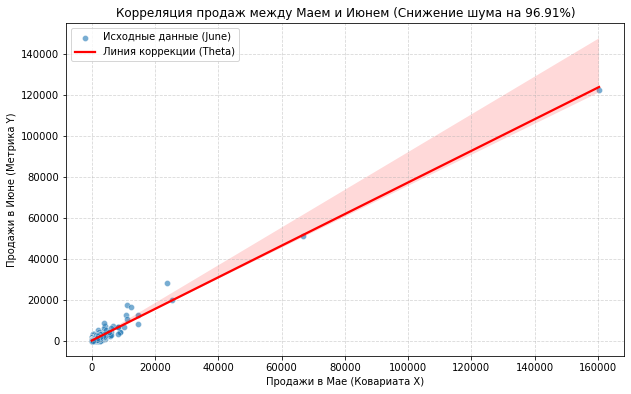

In [57]:
## Визуализируем
plt.figure(figsize=(10, 6))

# Рисуем точки (Май vs Июнь)
sns.scatterplot(data=df_cuped, x='May', y='June', alpha=0.6, label='Исходные данные (June)')

# Рисуем линию регрессии (как Тета "видит" связь)
sns.regplot(data=df_cuped, x='May', y='June', scatter=False, color='red', label='Линия коррекции (Theta)')

plt.title(f'Корреляция продаж между Маем и Июнем (Снижение шума на {96.91:.2f}%)')
plt.xlabel('Продажи в Мае (Ковариата X)')
plt.ylabel('Продажи в Июне (Метрика Y)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

На Scatter-plot видим:

- Высокая концентрация данных в левом нижнем углу - это малые города.
- Разреженные выбросы - крупные города

Несмотря на разный масштаб продаж, линейная связь (Theta - угол наклона) прослеживается на всех уровнях. 

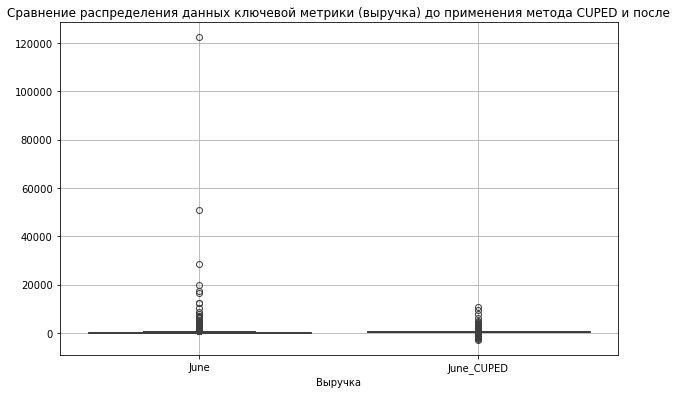

In [58]:
# Дополнительно построим ящики 
plt.figure(figsize=(10, 6))
sns.boxplot(df_cuped[['June','June_CUPED']])
plt.title('Сравнение распределения данных ключевой метрики (выручка) до применения метода CUPED и после')
plt.xlabel('Месяц')
plt.xlabel('Выручка')
plt.grid()
plt.show()

На boxplot мы видим, что после применения CUPED огромный выброс «схлопывается», а данные прижимаются к центру. Это наглядно демонстрирует как метод убирает индивидуальную волатильность объектов. Дисперсия падает, шум уходит, и уже можно применить t-test.

**Вывод:** Мы подтвердили, что CUPED эффективно корректирует метрику как для малых, так и для крупных сегментов, "притягивая" их к общему среднему и снижая общий шум системы на 96.9%. К таким данным можно применить t-test.

## Симуляция А/В тестирования

Т.к. у нас реальные денные, но нет доступа к сплитованию, то сделаем симуляцию (Synthetic A/B Test).

1. Разделим на группы: случайно делим 651 город на группу А (Контроль) и группу В (Тест).
2. Добавим эффект: Искусственно "улучшим" данные группы В в июне (считаем, что в этих городах прошла рекламная компания, которая подняла выручку на 25%).
3. Сравнним: Найдем этот эффект двумя способами:
        - Обычный t-test (на сырых данных June).
        - t-test + CUPED (на скорректированных данных June_CUPED).

### Сплитование

In [59]:
# 1. Рандомизация (50/50)
np.random.seed(42) # фиксируем, чтобы результат был повторяемым
df_cuped['group'] = np.random.choice(['A', 'B'], size=len(df_cuped))

### Проверка сплитования

Проверим пропорции выборок (Sample Ratio Mismatch, SRM)), в группе А и группе В должно быть равное количество городов.

In [60]:
set_sities_A = set(df_cuped['customer_city'].loc[df_cuped['group'] == 'A'])

In [61]:
set_sities_B = set(df_cuped['customer_city'].loc[df_cuped['group'] == 'B'])

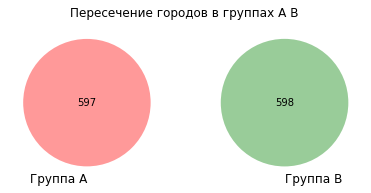

In [62]:
# Строим диаграмму Венна
v = venn2(subsets=[set_sities_A, set_sities_B], \
          set_labels=('Группа А', 'Группа B'))
plt.title("Пересечение городов в группах А В ")
plt.show()   

Видим, что сплитование сработало корректно, группы не пересекаются и поделены ~50/50.

#### Проверка сплитования А/А тестом

Проверим сплитование статистическим тестом на целевой метрике **(A/A-тест)** за май ДО ТЕСТА. Если рандомизатор сработал честно, то средняя выручка в группе А и группе В в мае будет примерно одинаковой. 

- Гипотеза H0 - выручка в обеих группах не различается
- Гипотеза H1 - выручка в обеих группах различается

In [63]:
t_stat, p_value = st.ttest_ind(df_cuped[df_cuped['group']=='A']['May'], 
                                df_cuped[df_cuped['group']=='B']['May'])

In [64]:
if p_value > 0.05:
    display(f'Сплитование корректно, группы А и В однородны по выручке в предпериоде,  p-value = {p_value:.20f}')
else:
    # <= 0.05
    display(f'Сплитование неудачное (перекос), нужно перерандомизировать, p-value = {p_value:.20f}')        

'Сплитование корректно, группы А и В однородны по выручке в предпериоде,  p-value = 0.81634428426250749133'

### Симуляция эффекта в тестовой группе

In [65]:
# 2. Добавляем искусственный эффект +25% для группы B в июне
lift = 1.25
df_cuped['June_lift'] = df_cuped['June']

In [66]:
df_cuped.loc[df_cuped['group'] == 'B', 'June_lift'] *= lift

In [67]:
# Пересчитываем CUPED-метрику с учетом нового June
df_cuped['June_CUPED'] = df_cuped['June_lift'] - theta * (df_cuped['May'] - mu_may)

### Сравнение статистических тестов

In [68]:
# 3. Считаем T-test на ОБЫЧНЫХ данных
t_stat, p_value = st.ttest_ind(df_cuped[df_cuped['group'] == 'B']['June_lift'],
                               df_cuped[df_cuped['group'] == 'A']['June'])
display(f'Тест Стьюдента: p-value = {p_value:.4f}')

'Тест Стьюдента: p-value = 0.4966'

In [69]:
# 4. Считаем T-test на CUPED данных
t_cuped, p_cuped = st.ttest_ind(df_cuped[df_cuped['group'] == 'B']['June_CUPED'],
                                df_cuped[df_cuped['group'] == 'A']['June_CUPED'])

display(f'CUPED тест:   p-value = {p_cuped:.10f}')

'CUPED тест:   p-value = 0.0435732746'

**Вывод:**

- Обычный t-тест не фиксирует лифт изменения метрики в 25% из-за ненормальности данных и высокой дисперсии.
- Использование метода CUPED позволило снизить дисперсию на 96% и провести t-test.
- Стат-значимость: p-value снизился с 0.49 до 0.043, что позволило выявить эффект.

## Итоговый вывод по проекту

В проекте использовались данные выручки городов маркетплейса Olist.

**Проблема данных:**  Исходное распределение выручки по городам характеризуется асимметрией и наличием выбросов. Из-за этого обычный t-тест не фиксирует лифт метрики даже в 25% (p-value = 0.49), так как эффект «тонет» в высокой дисперсии.

**Эффективность метода**: Я протестировала метод на разных уровнях воздействия. При лифте в 25% обычный t-тест все еще не мог пробить шум из-за специфики ритейл-данных (высокая волатильность). Использование CUPED позволило снизить стандартную ошибку настолько, что эффект стал статистически значимым. Это доказывает, что в условиях "шумных" данных без продвинутых методов оценки можно упустить даже очень крупные позитивные изменения в продукте. 

**Результат:** Применение метода CUPED с использованием исторических данных за май 2018 позволило снизить дисперсию целевой метрики на 96.9%. После снижения шума чувствительность теста значительно выросла. p-value снизился с 0.49 до 0.044, что позволило успешно обнаружить статистически значимый эффект и подтвердить успешность рекламной компании для роста выручки.

Проект подтверждает, что метод позволяет принимать верные бизнес-решения даже при умеренном объеме данных.